## Rule 3: Hiding Path Information

Based on the patterns in the BIRD dev set, we will identify tables that serve as bridges and exclude their information from the corresponding questions in the BIRD dev set

### Important Note

**_To generate the queries, you must include one development database ID in the first cell at a time. Run all the cells except for the last one each time._**

## 1. Retrieving the dev patterns for each database
The following cells retrieve the join patterns extracted from the development set queries of the BIRD benchmark. For this rule, we have divided these patterns into two sets: a training set and a test set. For now, we are working with the training patterns, which are stored in the `rule_original_patterns/train` folder. The folder can be accessed here: [Train Patterns](https://drive.google.com/drive/folders/1i87JHEK3j348RciQNZem9OpGk2BmPuAj).

The folder contains data for each development database, including a pickle file that contains 80% of the patterns for each database (the patterns are shuffled).

In [199]:
import os
import pickle
from pathlib import Path

def retrieve_all_dev_patterns(folder_path):
    """
    Retrieve all subgraphs from the pickle files in the folder.
    
    Args:
        folder_path (str): The path to the folder containing the .pkl files.
        
    Returns:
        list: A list of all subgraphs from the folder.
    """
    folder = Path(folder_path)

    for file_name in folder.glob('patterns.pkl'):
        try:
            with file_name.open('rb') as f:
                subgraphs = pickle.load(f)
        except (ValueError, KeyError, pickle.UnpicklingError) as e:
            print(f"Skipping file {file_name.name}: {e}")

    return subgraphs

# Example usage:
db_id = 'toxicology'
folder_path = f'rule_original_patterns/train/{db_id}/'
# Retrieve all subgraphs from the folder
database_subgraphs = retrieve_all_dev_patterns(folder_path)
print(f"Found {len(database_subgraphs)} subgraphs.")

Found 10 subgraphs.


In this cell, the schema graph for each database is retrieved from the corresponding pickle file stored in the `main_graphs_pickles` folder under `dev_dbs_unnested`. The folder can be accessed here: [Schema Graphs](https://drive.google.com/drive/folders/18a1XT3zZFJO-k28OQT7Cqcm9VlZ7qljS).


In [215]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import pickle
from datetime import datetime

# Load the schema (main graph) from the pickle file
schema_path = f'dev_dbs_unnested/main_graphs_pickles/{db_id}_graph.pkl'
with open(schema_path, 'rb') as f:
    schema = pickle.load(f)


def display_subgraph(schema, subgraph, subgraph_number):
    """
    Display and save a subgraph within the main schema.

    Args:
        schema (nx.Graph): The main graph schema.
        subgraph (nx.Graph): The subgraph to display.
        subgraph_number (int): The number of the subgraph for labeling.
        rule (str): The rule this subgraph belongs to (either 'rule_1' or 'rule_2').
        time_period (str): Either 'pre_rule' or 'post_rule' indicating the time period.
        db_id (str): The database ID.
    """
    # Create a figure for the plot
    plt.figure(figsize=(10, 10))
    
    # Draw the entire schema in light gray
    pos = nx.spring_layout(schema)  # Node positions using spring layout
    nx.draw(schema, pos, with_labels=True, node_color='lightgray', edge_color='black', 
            node_size=1000, font_size=10)

    # Check if the subgraph is None or has nodes
    if subgraph is not None and subgraph.number_of_nodes() > 0:  # Draw the subgraph only if it contains nodes
        # Draw the subgraph nodes and edges
        nx.draw_networkx_nodes(subgraph, pos, node_color='lightblue', node_size=1000)
        nx.draw_networkx_edges(subgraph, pos, edge_color='blue', width=2)

        # Create edge labels for the subgraph, fallback to schema if needed
        edge_labels = {
            (u, v): edge_data.get('label', schema[u][v].get('label', 'No Label'))
            for u, v, edge_data in subgraph.edges(data=True)
        }

        # Draw the edge labels
        nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_color='red', font_size=7)

    # Add title indicating the subgraph number
    plt.title(f'Subgraph {subgraph_number}')
    plt.show()
    plt.close()  


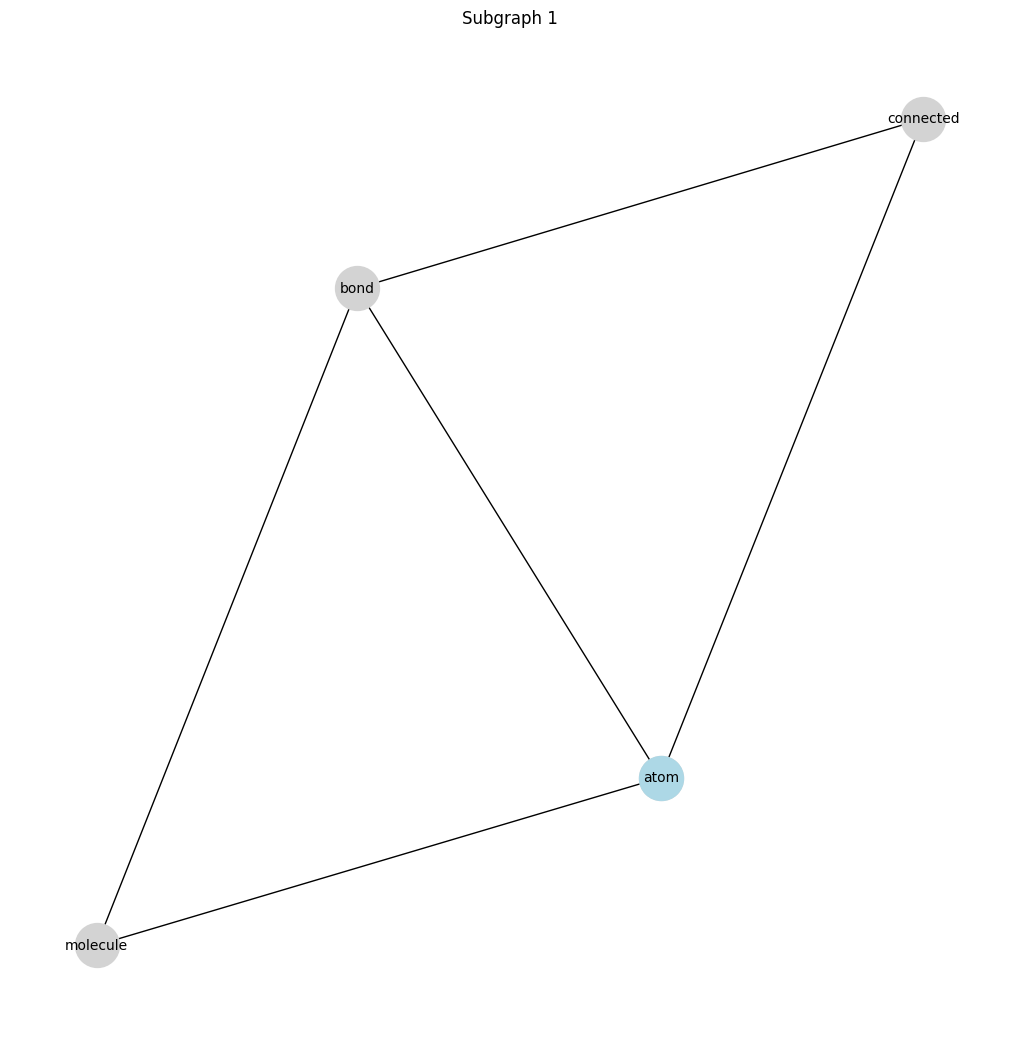

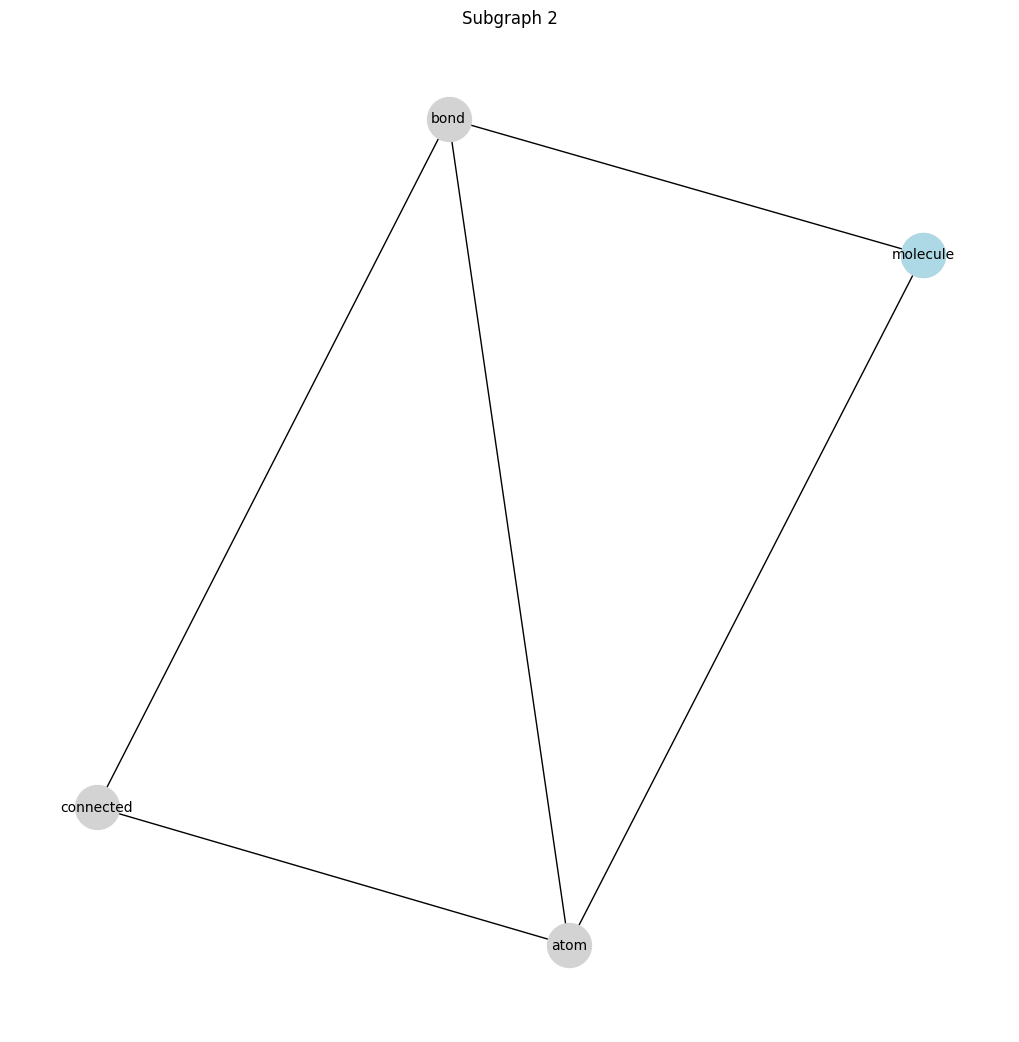

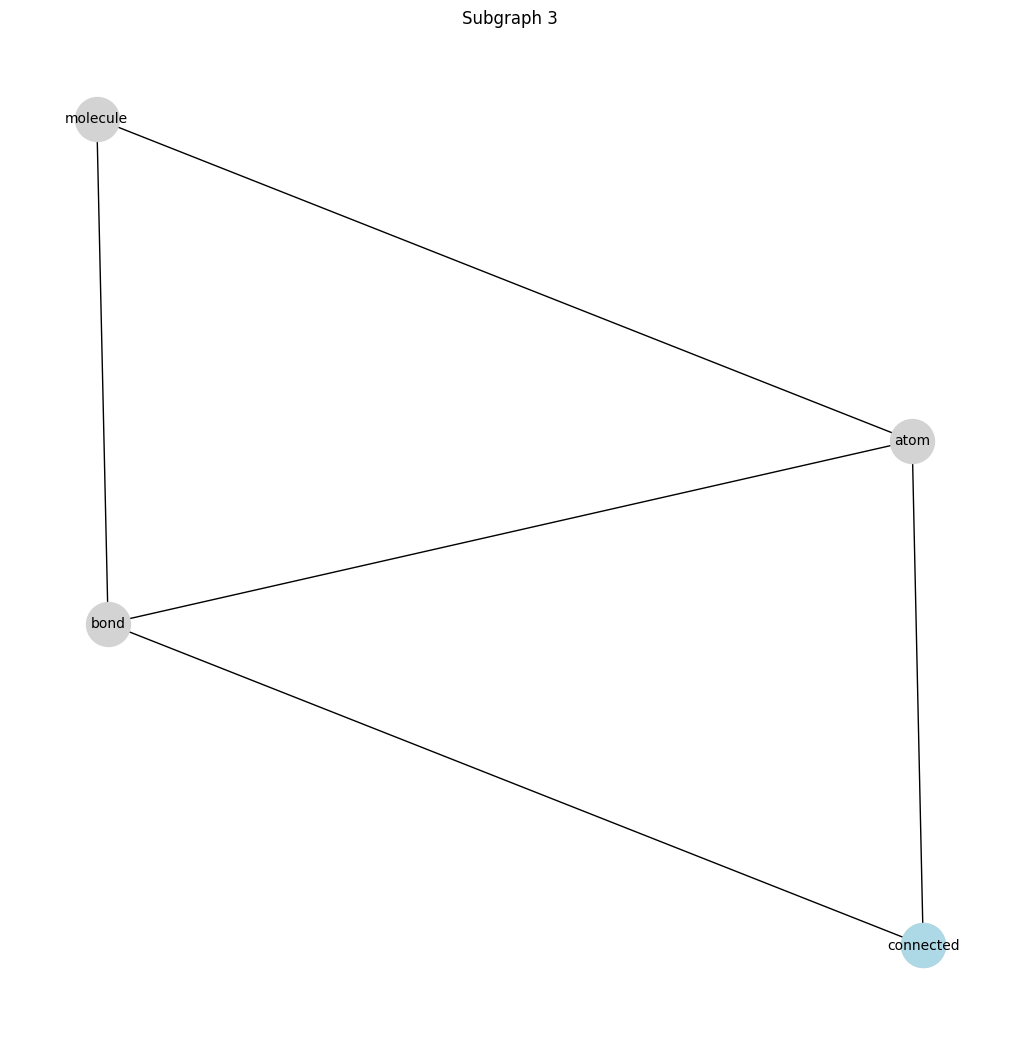

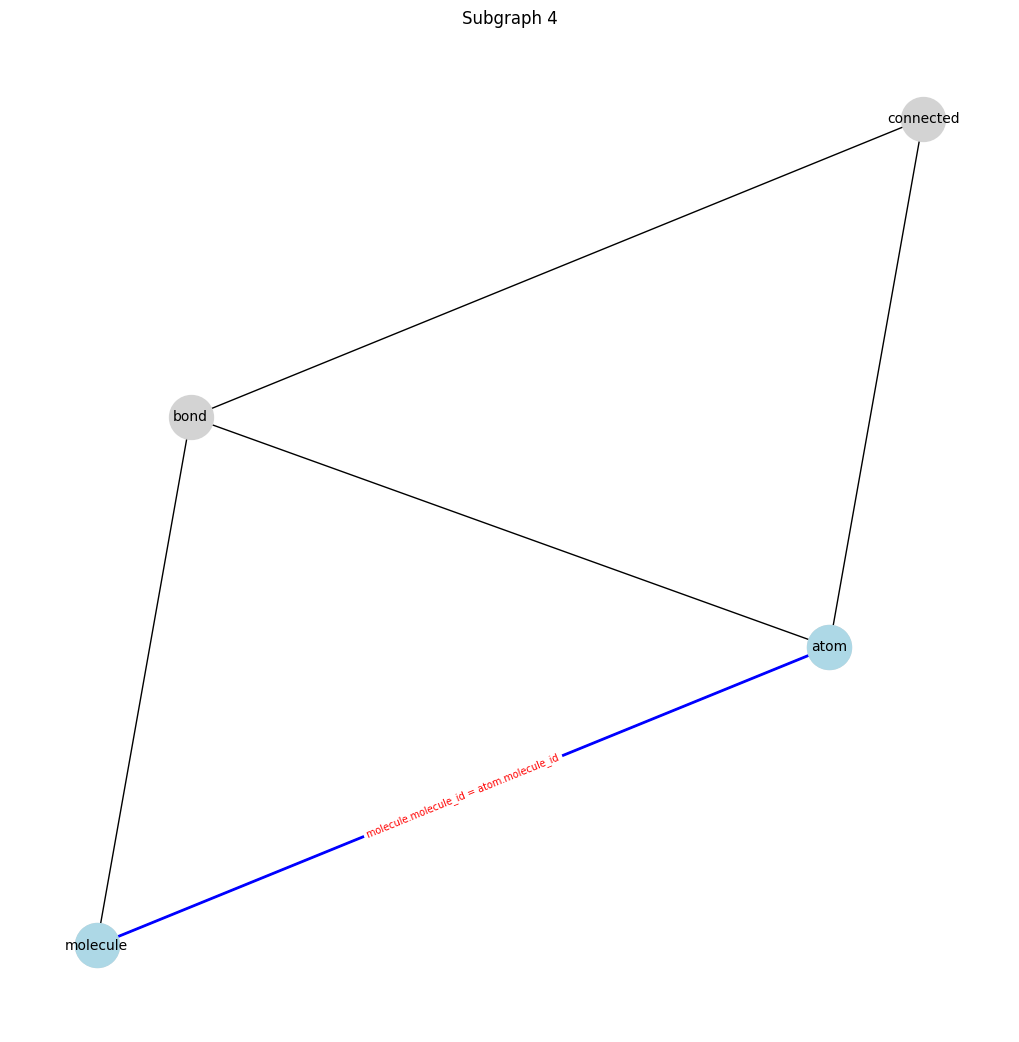

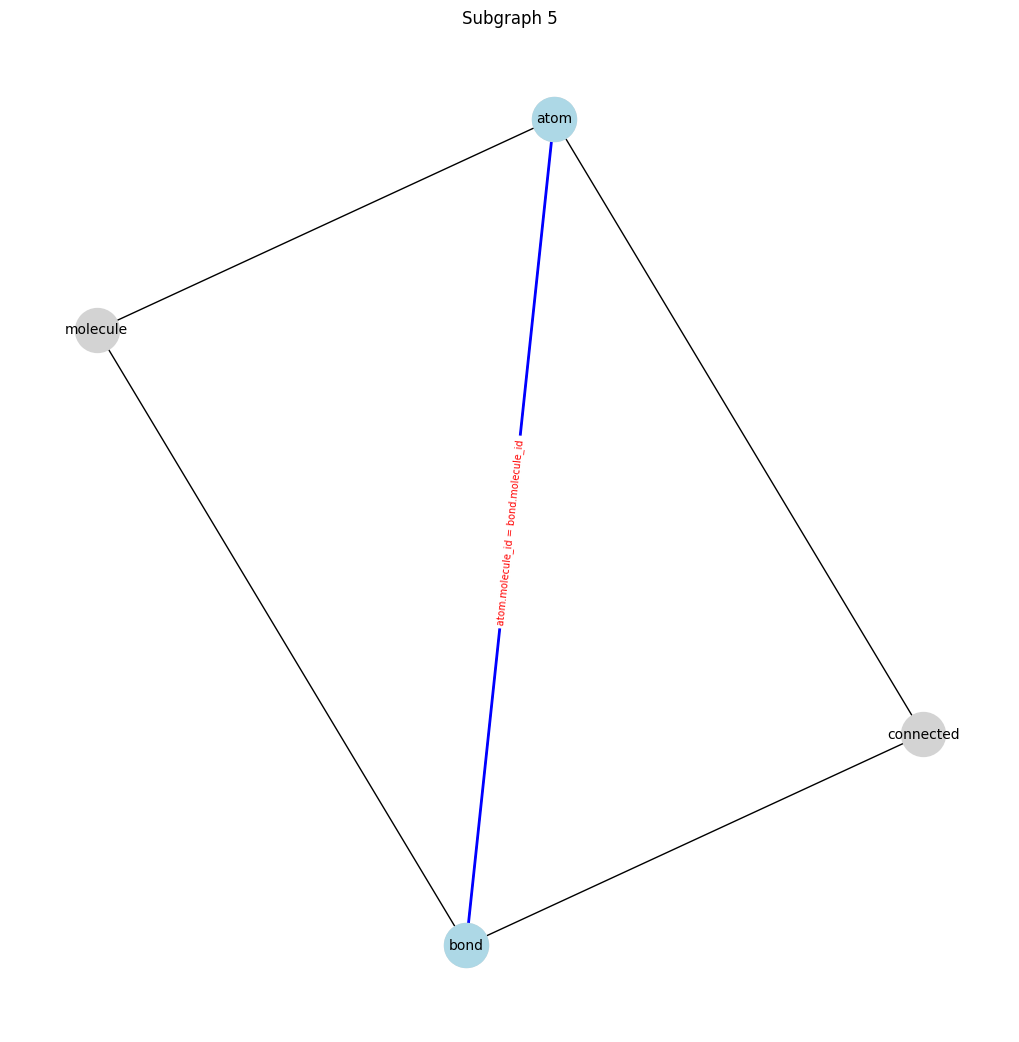

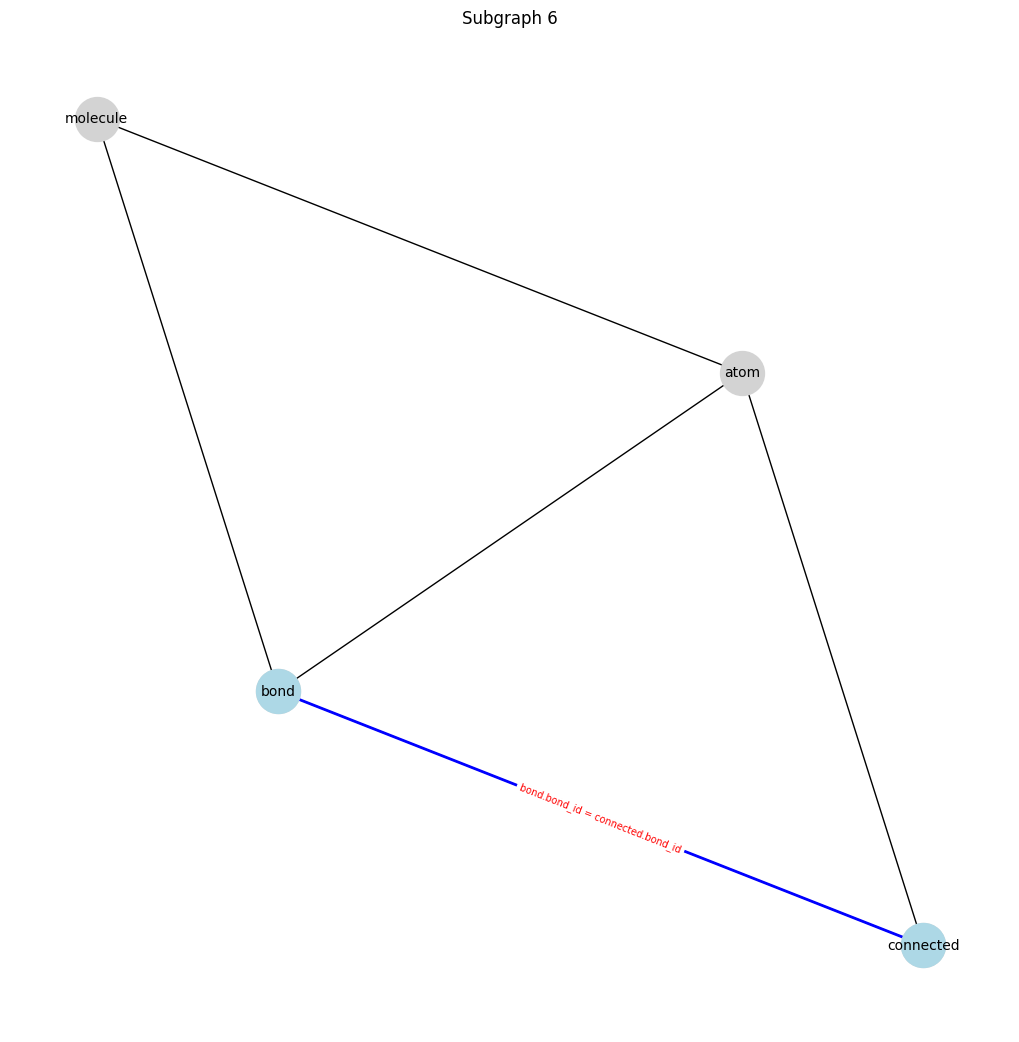

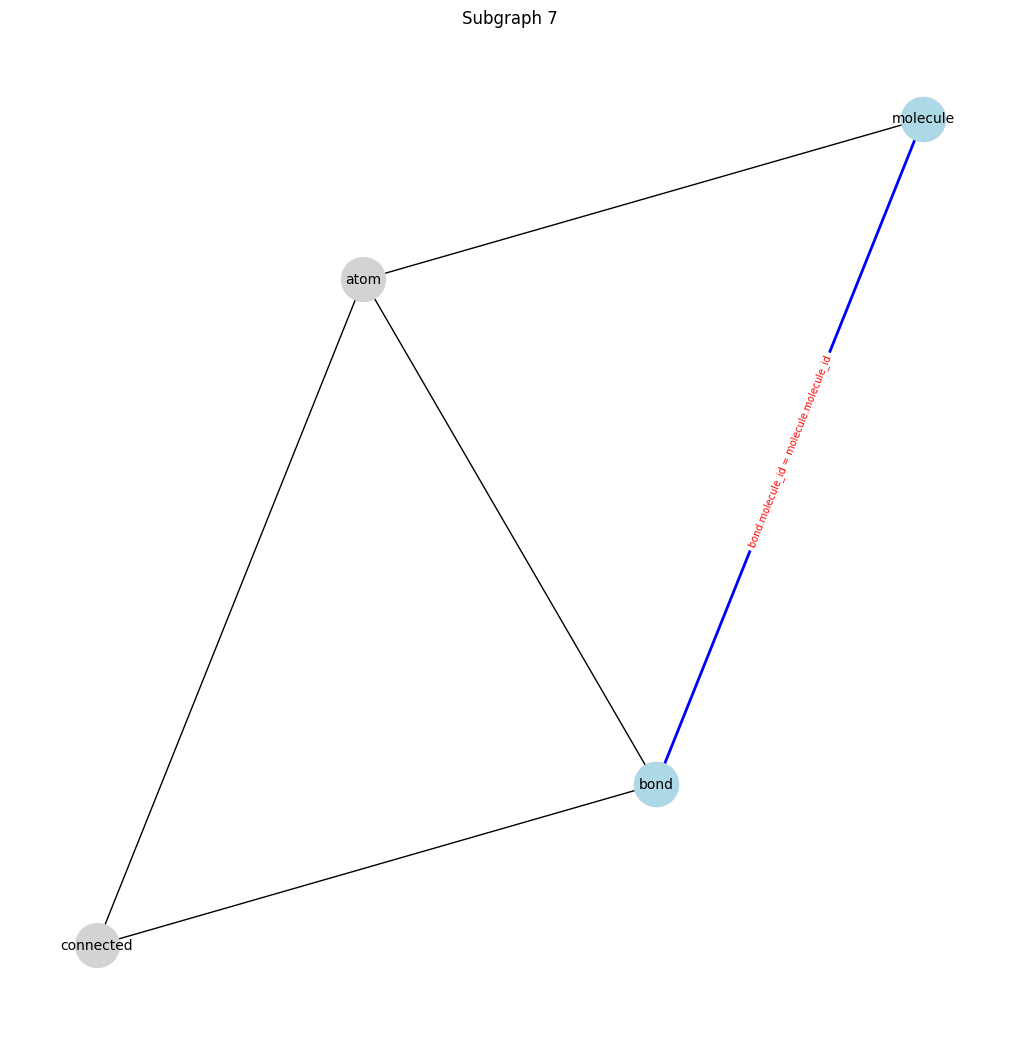

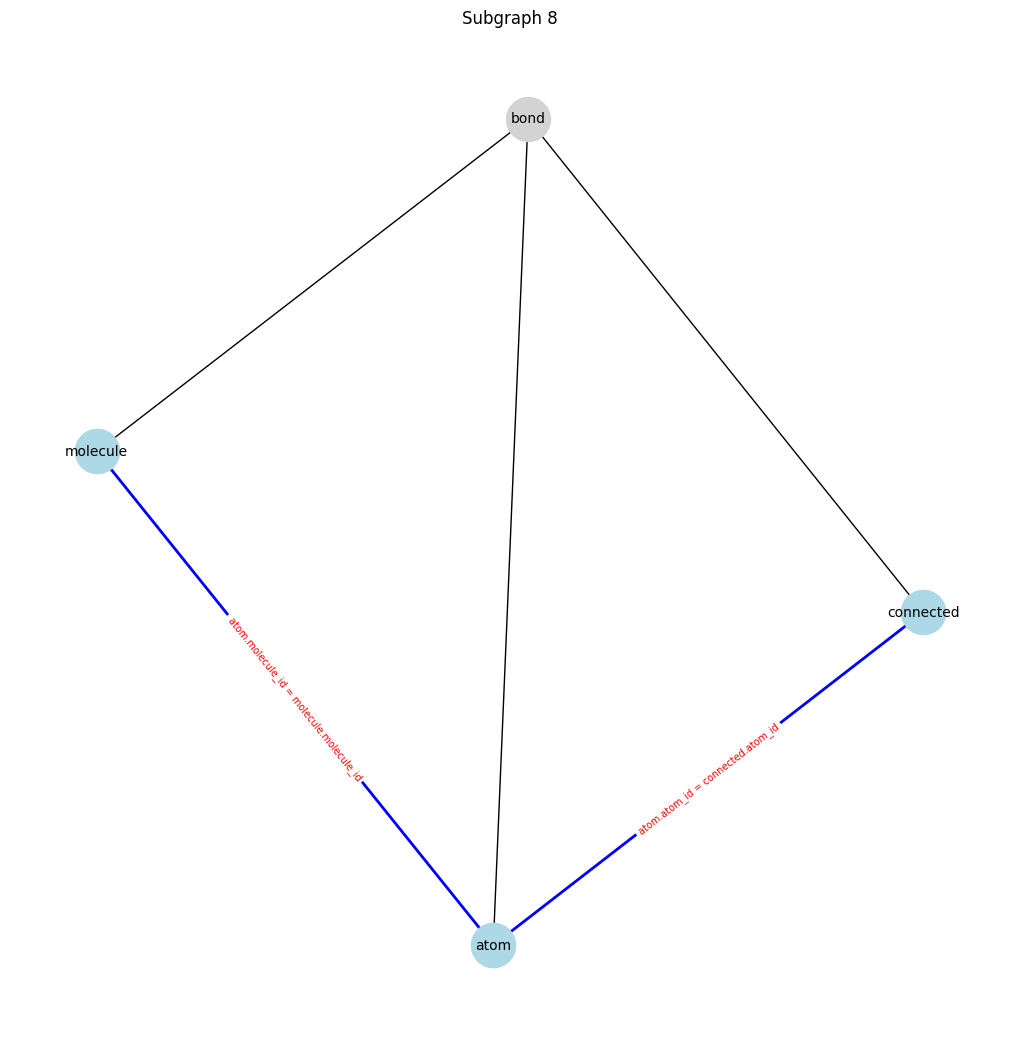

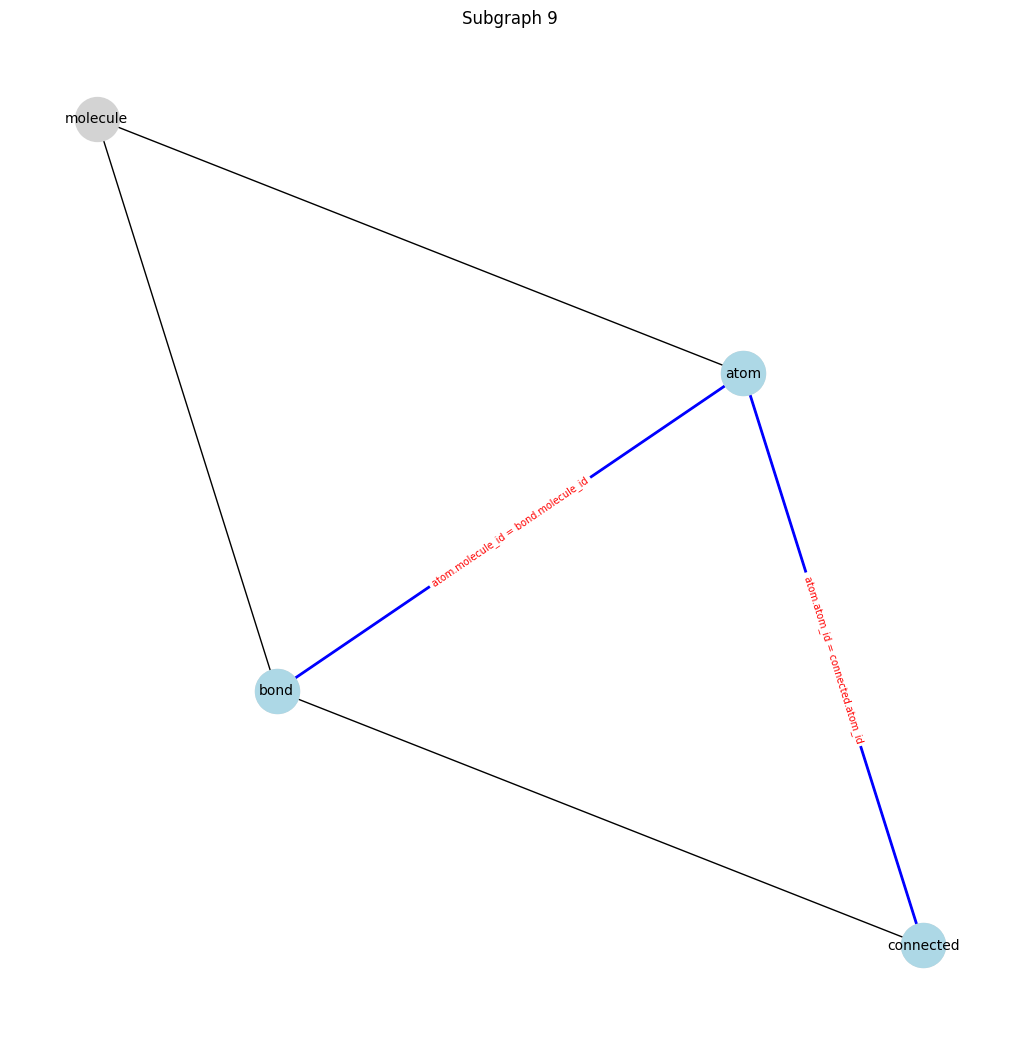

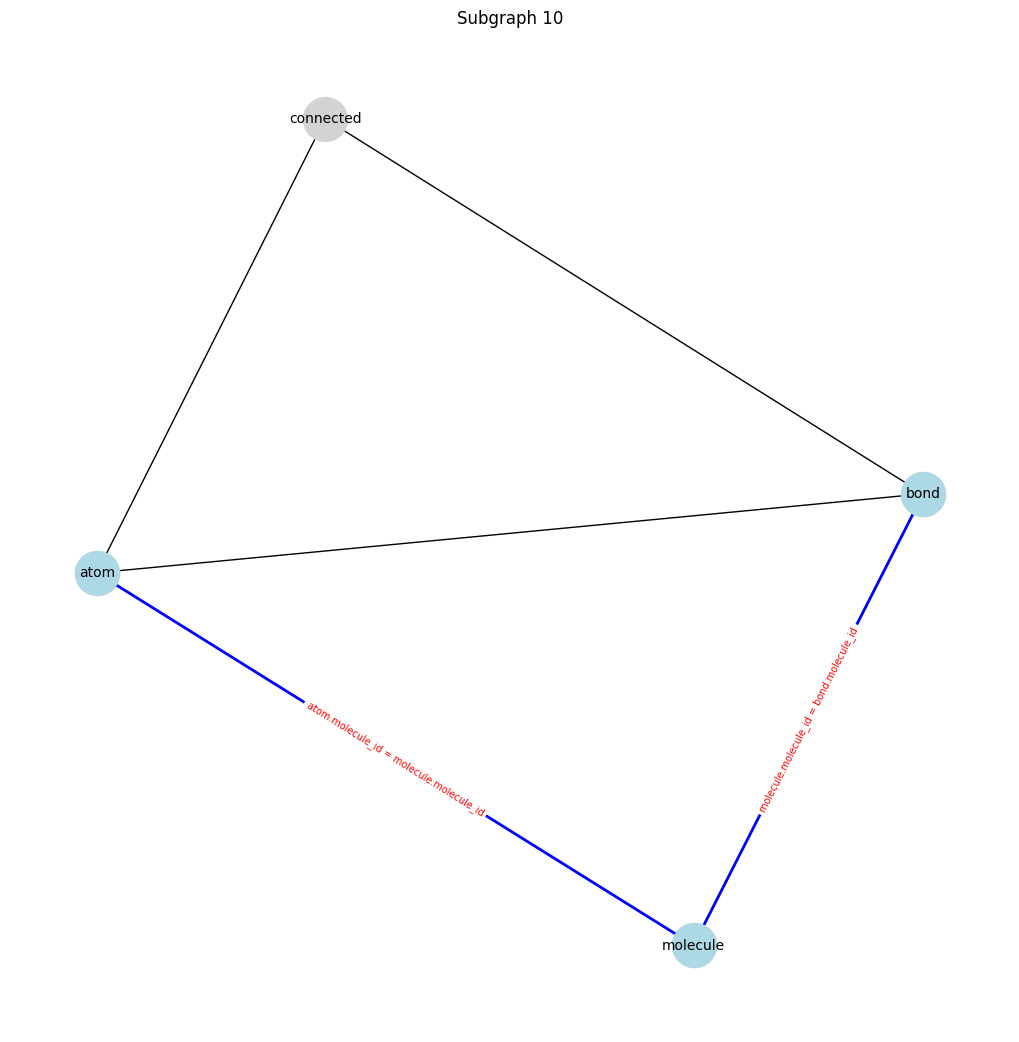

In [217]:
# Display all subgraphs
subgraphs_sorted = sorted(database_subgraphs, key=lambda x: x.number_of_nodes())  # Sort by number of nodes
for i, subgraph in enumerate(subgraphs_sorted, start=1):
    display_subgraph(
            schema=schema,
            subgraph=subgraph,
            subgraph_number=i,
    )


## 2. Identifying the candidate table to hide (the most central table to the query)

In [202]:
# Precompute schema centrality once, as it does not depend on the subgraphs
schema_centrality = nx.degree_centrality(schema)

subgraphs_with_candidates = []

for subgraph in subgraphs_sorted:
    if subgraph.number_of_nodes() < 3:
        continue

    # Compute betweenness centrality for the current subgraph
    betweenness_centrality = nx.betweenness_centrality(subgraph)
    max_betweenness = max(betweenness_centrality.values())
    
    # Find nodes with the maximum betweenness centrality
    candidates = [(node, score) for node, score in betweenness_centrality.items() if score == max_betweenness]

    if len(candidates) == 1:
        # Only one candidate, select it
        selected_table = candidates[0][0]
    else:
        # Find the candidate with the highest schema centrality
        selected_table = max(candidates, key=lambda x: schema_centrality.get(x[0], 0))[0]

    subgraphs_with_candidates.append({"subgraph": subgraph, "candidate_table": selected_table})

print(subgraphs_with_candidates)

[{'subgraph': <networkx.classes.graph.Graph object at 0x1461707d0>, 'candidate_table': 'atom'}, {'subgraph': <networkx.classes.graph.Graph object at 0x1460f8110>, 'candidate_table': 'atom'}, {'subgraph': <networkx.classes.graph.Graph object at 0x14070d790>, 'candidate_table': 'molecule'}]


the table to be hidden:  atom


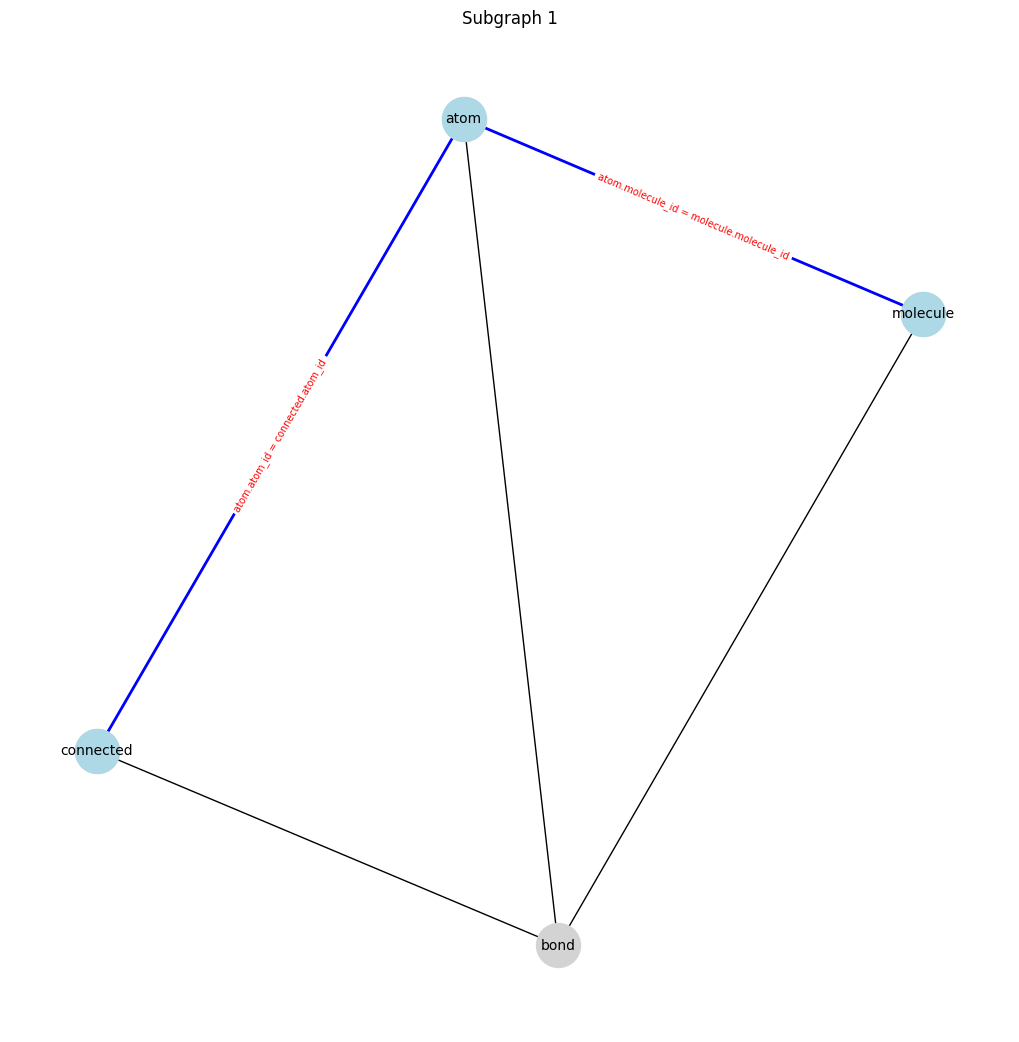

the table to be hidden:  atom


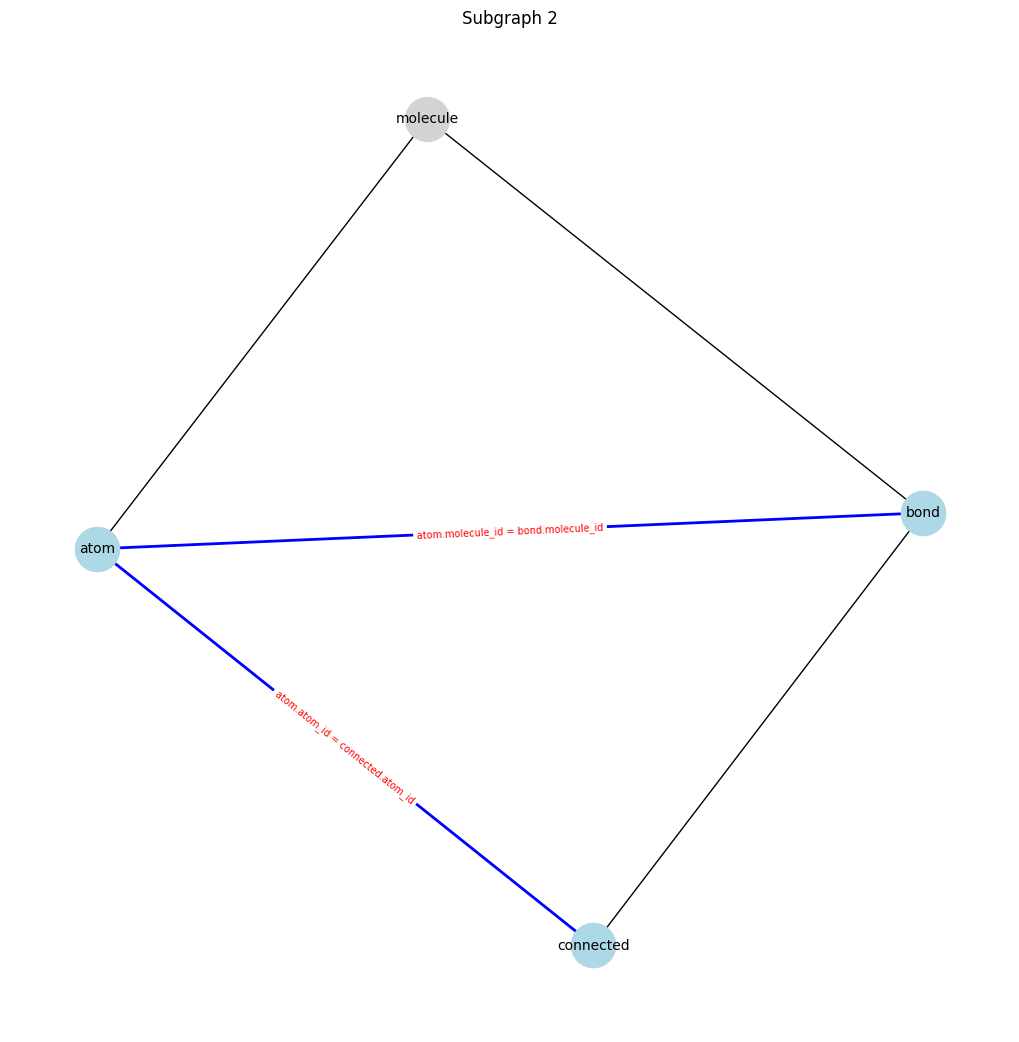

the table to be hidden:  molecule


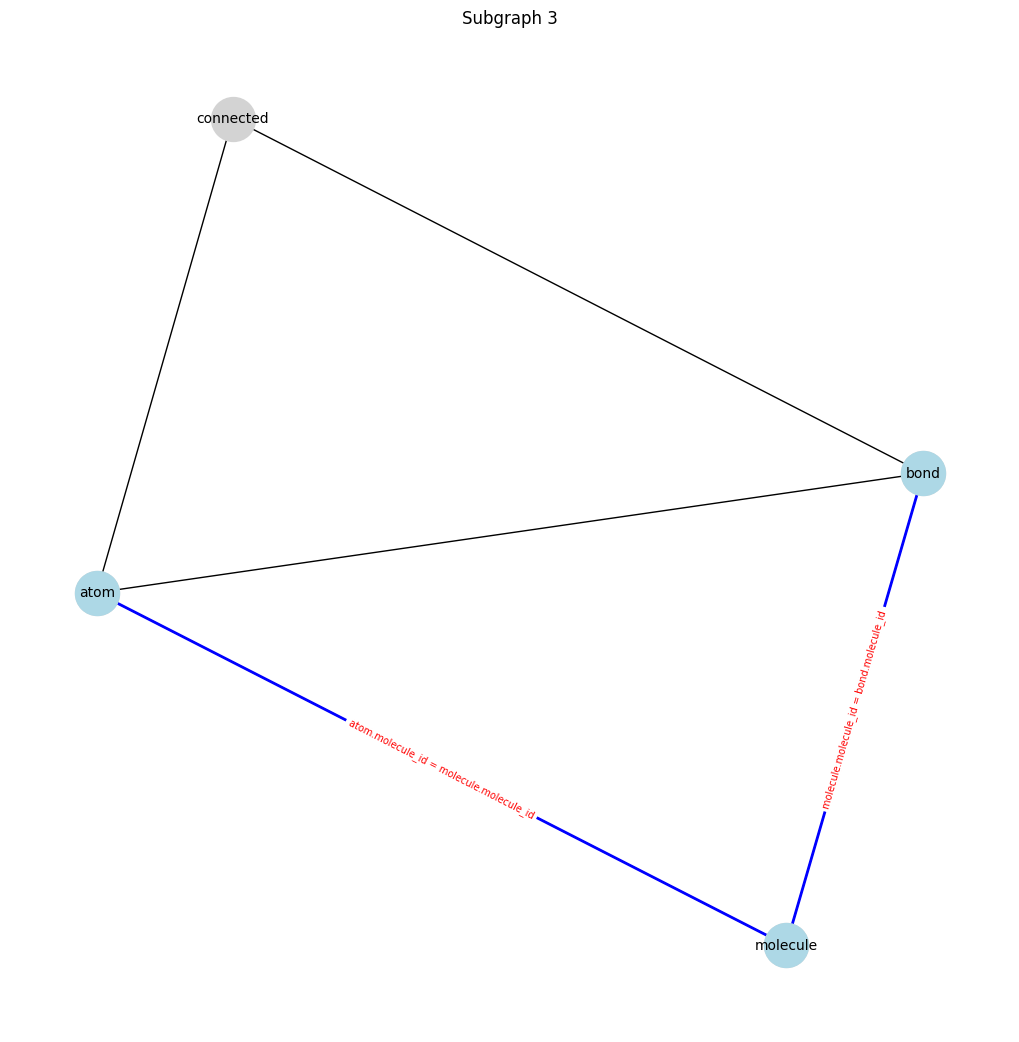

In [203]:
for i, element in enumerate(subgraphs_with_candidates, start=1):
    # Display all subgraphs
    print("the table to be hidden: ", element.get("candidate_table"))
    display_subgraph(
            schema=schema,
            subgraph=element.get("subgraph"),
            subgraph_number=i,
    )

## 3. Finding the SQL queries for each pattern
In this cell, we match each pattern with the identified candidate table using the SQL queries in the development set. The pattern details are stored in the `patterns_with_questions` folder under `dev_dbs_unnested`, which can be accessed here: [Patterns with Questions](https://drive.google.com/drive/folders/1m-i2-Y_4Ju-VNA6NmzEi74SroCDVMkRt).  

You can rename the folder to `patterns` or simply change the path as needed.

In [204]:
import os
import json
import sys
import networkx as nx

# Base directories
pattern_base_dir = "dev_dbs_unnested/patterns"
output_base_dir = "rules_outputs/rule_3"
os.makedirs(output_base_dir, exist_ok=True)  # Ensure the output directory exists

def find_matching_sql_and_questions(subgraph, candidate_table, pattern_file_path):
    """
    Find matching SQL queries and questions for the given subgraph and candidate table.
    """
    subgraph_tables = subgraph.nodes()
    subgraph_join_relations = list(nx.get_edge_attributes(subgraph, 'label').values())

    with open(pattern_file_path, 'r', encoding='utf-8') as f:
        patterns = json.load(f)

    matching_queries = []
    for pattern in patterns:
        pattern_tables = [e.get("table_name") for e in pattern.get("Tables", [])]
        pattern_join_relations = pattern.get("Join_relations_without_aliases", [])

        if (set(subgraph_tables) == set(pattern_tables) and 
            set(subgraph_join_relations) == set(pattern_join_relations)):
            
            question = pattern.get("question", "")
            print("question: ", question, " | candidate_table: ", candidate_table)
            # Additional condition: check if candidate_table is in the question
            if candidate_table in question:
                matching_queries.append({
                    "SQL": pattern.get("SQL"),
                    "question": question,
                })
    return matching_queries


def process_subgraphs(subgraphs_with_candidates, db_id):
    """
    Process each subgraph, find matching queries, and write results to JSON.
    """
    pattern_file_path = f'{pattern_base_dir}/{db_id}_unnested_patterns.json'
    output_file_path = f'{output_base_dir}/{db_id}_outputs.json'

    output_data = []  # Store all results for this db_id

    for subgraph_data in subgraphs_with_candidates:
        candidate_table = subgraph_data["candidate_table"]
        subgraph = subgraph_data["subgraph"]

        # Find matching queries
        matching_queries = find_matching_sql_and_questions(subgraph, candidate_table, pattern_file_path)

        # Register matches
        for match in matching_queries:
            output_data.append({
                "SQL": match["SQL"],
                "candidate_table": candidate_table,
                "db_id": db_id,
                "original_question": match["question"],
                "new_question": ""  # Initialize as empty
            })

    # Write results to the JSON file
    if len(output_data) == 0:
        print(f"No matching queries found for {db_id}.")
        return
    else: 
        with open(output_file_path, 'w', encoding='utf-8') as f:
            json.dump(output_data, f, indent=4)

    print(f"Processed {db_id}: {len(output_data)} matching queries written to {output_file_path}")


# Example usage
if subgraphs_with_candidates:
    process_subgraphs(subgraphs_with_candidates, db_id)
else:
    print(f"No subgraphs found for {db_id}.")


question:  Indicate which atoms are connected in non-carcinogenic type molecules.  | candidate_table:  atom
question:  What elements are in a double type bond?  | candidate_table:  atom
question:  What is the percentage of carcinogenic molecules in triple type bonds?  | candidate_table:  molecule
question:  Calculate the total atoms with triple-bond molecules containing the element phosphorus or bromine.  | candidate_table:  molecule
question:  How many bond id have element iodine?  | candidate_table:  molecule
question:  List down two molecule id of triple bond non carcinogenic molecules with element carbon.  | candidate_table:  molecule
question:  What is the carcinogenic label for bond TR001_2_4?  | candidate_table:  molecule
question:  What is the atom ID of double bonded carbon in TR012 molecule?  | candidate_table:  molecule
Processed toxicology: 5 matching queries written to rules_outputs/rule_3/toxicology_outputs.json


## 4. Hiding the path information
The hiding part is done using GPT-4o mini. You can use your API key stored in a `.env` file located here.

In [205]:
import openai
import os
import json
import sys
from dotenv import load_dotenv

load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")

# Load the matching queries from the JSON file
output_file_path = f'{output_base_dir}/{db_id}_outputs.json'

if not os.path.exists(output_file_path):
    print(f"Error: The file '{output_file_path}' does not exist. Stopping execution.")
    sys.exit(1)
with open(output_file_path, 'r', encoding='utf-8') as f:
    matching_queries = json.load(f)

# Divide queries into groups of 4
group_size = 3
groups = [matching_queries[i:i + group_size] for i in range(0, len(matching_queries), group_size)]

for group in groups:
    # Prepare prompt for the current group
    additional_lines = ''
    for matching_query in group:
        if matching_query["candidate_table"] in matching_query["original_question"]:
            additional_lines += f"SQL Query: {matching_query['SQL']}\n"
            additional_lines += f"Mapped Question: {matching_query['original_question']}\n\n"
            additional_lines += f"Task: Hide the candidate table: {matching_query['candidate_table']}\n\n"

    prompt = f'''The following task involves SQL queries along with their corresponding mapped questions. Each SQL query is represented as a graph, where each table is a node, and the join relations are labeled as edges between the nodes. The **candidate table** is provided and is the most central table in the graph, making it essential for the path information that leads to the creation of the SQL query.

### Task Instructions:
- Your goal is to **hide** the specific details about the candidate table within the mapped questions.
- **Reasoning**: In each mapped question, the candidate table should not be explicitly mentioned by its name, but the question must still reflect the relationships in the SQL query in a generalizable way. To do this, **generalize the candidate table's name** while keeping terms that are still relevant to the database context (in this case, the database is {db_id}). The key is to **preserve the meaning** of the question without revealing the specific table.

### Example:

**SQL Query**: 
SELECT name, salary FROM employees e JOIN departments d ON e.department_id = d.department_id WHERE d.department_name = 'HR'

**Mapped Question**:  
“What is the salary and name of employees working in the HR department?”

**Task**: Hide the candidate table (`employees`) in the question.

**Modified Question**:  
“What is the salary and name of individuals working in the HR department?”

### End of the Example
### The questions you will modify:

{additional_lines}

Please provide the list of new questions in bullets directly, don't generate any extra text, just the modified questions. And remember the new generated questions should not have the candidate table name in them.
'''

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]

    # Get response from the LLM
    response = openai.ChatCompletion.create(
        model="gpt-4o-mini",
        messages=messages,
        max_tokens=300,
        temperature=0.7,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
    )

    # Process LLM response
    generated_text = response.choices[0]['message']['content'].strip()

    modified_questions = [q.strip().replace("- ", "") for q in generated_text.split("\n") if q.startswith("-")]

    # Update each matching_query with the modified question
    for matching_query, new_question in zip(group, modified_questions):
        matching_query["new_question"] = new_question

# Save updated data back to the JSON file
with open(output_file_path, 'w', encoding='utf-8') as f:
    json.dump(matching_queries, f, indent=4, ensure_ascii=False)

print(f"Updated questions saved back to {output_file_path}.")


The prompt:  The following task involves SQL queries along with their corresponding mapped questions. Each SQL query is represented as a graph, where each table is a node, and the join relations are labeled as edges between the nodes. The **candidate table** is provided and is the most central table in the graph, making it essential for the path information that leads to the creation of the SQL query.

### Task Instructions:
- Your goal is to **hide** the specific details about the candidate table within the mapped questions.
- **Reasoning**: In each mapped question, the candidate table should not be explicitly mentioned by its name, but the question must still reflect the relationships in the SQL query in a generalizable way. To do this, **generalize the candidate table's name** while keeping terms that are still relevant to the database context (in this case, the database is toxicology). The key is to **preserve the meaning** of the question without revealing the specific table.

###

## 5. Final queries 
This cell should be run after generating the new questions for each `db_id`. It gathers all the previously generated data in one place. To run this, you will need the `bird_dev.json` file, which is the development set file. It can be found here: [bird_dev.json](https://drive.google.com/drive/folders/10WxERhJh5ZWbad9fwNyR_51hWkSxFKr4).


In [214]:
import os
import json

# Paths to the required files
bird_dev_path = "bird_dev.json"
rule_outputs_dir = "rules_outputs/rule_3"
output_file_path = "dev_3.json"
sql_output_path = "dev_3.sql"

# Load bird_dev.json
with open(bird_dev_path, 'r', encoding='utf-8') as f:
    bird_dev_data = json.load(f)

# Initialize a list for storing the new dev_3 data
dev_3_data = []
sql_queries = []  # To store SQL queries for the .sql file
question_id = 0  # Initialize question_id counter

# Read files from rule_outputs/rule_3/
for filename in os.listdir(rule_outputs_dir):
    file_path = os.path.join(rule_outputs_dir, filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        rule_data = json.load(f)
    
    for rule_entry in rule_data:
        candidate_table = rule_entry.get("candidate_table", "").lower()
        old_question = rule_entry.get("original_question", "").lower()
        new_question = rule_entry.get("new_question", "").lower()

        # Skip if the candidate table exists in the new question
        if candidate_table and candidate_table in new_question:
            continue
        
        # Match new questions with bird_dev questions (case insensitive)
        for bird_entry in bird_dev_data:
            bird_question = bird_entry.get("question", "").lower()
            if bird_question == old_question:
                # Add the matched data to dev_3_data
                dev_3_data.append({
                    "question_id": question_id,
                    "db_id": rule_entry["db_id"],
                    "question": rule_entry["new_question"],
                    "evidence": bird_entry.get("evidence", ""),  # Add evidence if it exists
                    "SQL": rule_entry["SQL"],
                    "difficulty": bird_entry.get("difficulty", "unknown")  # Default difficulty to 'unknown' if not present
                })
                
                # Add SQL query to sql_queries
                sql_queries.append(f"{rule_entry['SQL']}\t{rule_entry['db_id']}")
                
                # Increment the question_id
                question_id += 1

# Write dev_3_data to dev_3.json
with open(output_file_path, 'w', encoding='utf-8') as f:
    json.dump(dev_3_data, f, indent=4, ensure_ascii=False)

# Write SQL queries to dev_3.sql
with open(sql_output_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(sql_queries))

print(f"dev_3.json has been created with {len(dev_3_data)} entries.")
print(f"dev_3.sql has been created with {len(sql_queries)} SQL queries.")



dev_3.json has been created with 34 entries.
dev_3.sql has been created with 34 SQL queries.
